# 02 - Analyse Exploratoire Univariée (Univariate EDA)
## Projet de Prédiction des Maladies Cardiovasculaires

Ce notebook est dédié à **l'analyse exploratoire univariée** des variables du dataset cardiovasculaire.  
L'objectif est d'étudier chaque variable individuellement afin de :
1. **Comprendre les distributions**, la tendance centrale et la dispersion de chaque caractéristique.
2. **Détecter les anomalies**, valeurs aberrantes (*outliers*) et incohérences cliniques (ex: valeurs nulles physiologiquement impossibles).
3. **Évaluer l'équilibre des classes** et la représentativité de la population étudiée.
4. **Guider le prétraitement des données** (imputation, encodage, normalisation) et préparer l'analyse bivariée.

---

### 0. Configuration de l'environnement et imports

In [1]:
# Importation des bibliothèques nécessaires
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuration de l'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Configuration esthétique Seaborn et Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

### Chargement robuste du dataset

In [2]:
# Détection automatique du chemin du fichier CSV
possible_paths = [
    os.path.join("data", "cardiovascular.csv"),
    os.path.join("notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "data", "cardiovascular.csv")
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Le fichier 'cardiovascular.csv' est introuvable dans les répertoires standards.")

print(f"Chargement des données depuis : {csv_path}")
df = pd.read_csv(csv_path)
print(f"Dimensions du dataset : {df.shape[0]} observations, {df.shape[1]} colonnes.")
df.head()

Chargement des données depuis : data\cardiovascular.csv
Dimensions du dataset : 1000 observations, 14 colonnes.


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


> ℹ️ **Note méthodologique sur `patientid` :**  
> La variable `patientid` représente l'identifiant unique attribué à chaque patient (1000 valeurs distinctes).  
> Elle ne possède aucune signification biologique ni prédictive et sera donc **exclue** de l'analyse de distribution et des futurs modèles prédictifs.

---
## 1. Analyse des Variables Catégorielles et Ordinales

Afin d'assurer une interprétation médicale claire et intuitive, nous créons une copie du DataFrame (`df_cat`) dans laquelle chaque variable codée numériquement est traduite par son libellé clinique explicite.

In [3]:
# Création d'une copie avec les libellés médicaux explicites
df_cat = df.copy()

# 1. Target (Présence de maladie cardiovasculaire)
df_cat['target'] = df_cat['target'].map({
    0: 'Sain (Pas de MCV)',
    1: 'Atteint (Présence MCV)'
}).astype('category')

# 2. Gender (Sexe)
df_cat['gender'] = df_cat['gender'].map({
    0: 'Femme',
    1: 'Homme'
}).astype('category')

# 3. Chest Pain Type (Type de douleur thoracique)
df_cat['chestpain'] = df_cat['chestpain'].map({
    0: 'Asymptomatique',
    1: 'Angine atypique',
    2: 'Douleur non angineuse',
    3: 'Angine typique'
}).astype('category')

# 4. Fasting Blood Sugar (Glycémie à jeun > 120 mg/dL)
df_cat['fastingbloodsugar'] = df_cat['fastingbloodsugar'].map({
    0: 'Normale (≤ 120 mg/dL)',
    1: 'Élevée (> 120 mg/dL)'
}).astype('category')

# 5. Resting ECG (Résultats électrocardiographiques au repos)
df_cat['restingrelectro'] = df_cat['restingrelectro'].map({
    0: 'Normal',
    1: 'Anomalie onde ST-T',
    2: 'Hypertrophie ventriculaire gauche'
}).astype('category')

# 6. Exercise Induced Angina (Angine induite par l'effort)
df_cat['exerciseangia'] = df_cat['exerciseangia'].map({
    0: 'Non',
    1: 'Oui'
}).astype('category')

# 7. Slope (Pente du segment ST à l'effort maximal)
df_cat['slope'] = df_cat['slope'].map({
    0: 'Non documenté (0)',
    1: 'Ascendante (Upsloping)',
    2: 'Plate (Flat)',
    3: 'Descendante (Downsloping)'
}).astype('category')

# 8. Number of Major Vessels (Nombre de vaisseaux majeurs colorés par fluoroscopie)
df_cat['noofmajorvessels'] = df_cat['noofmajorvessels'].map({
    0: '0 vaisseau',
    1: '1 vaisseau',
    2: '2 vaisseaux',
    3: '3 vaisseaux'
}).astype('category')

### Fonction utilitaire pour variables catégorielles

Cette fonction génère un diagramme en barres enrichi des **effectifs exacts** et des **pourcentages (%)** pour chaque modalité, accompagné d'un tableau récapitulatif.

In [4]:
def plot_categorical_distribution(data, column, title, palette="Blues_r"):
    """
    Trace la distribution d'une variable catégorielle avec affichage des effectifs,
    pourcentages sur les barres et tableau récapitulatif.
    """
    counts = data[column].value_counts(dropna=False)
    percentages = data[column].value_counts(normalize=True, dropna=False) * 100
    summary_df = pd.DataFrame({
        'Effectif': counts,
        'Pourcentage (%)': percentages.round(1)
    })
    
    order = counts.index.tolist()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(x=order, y=counts.values, order=order, hue=order, palette=palette, legend=False, ax=ax)
    
    total = len(data)
    for p in ax.patches:
        height = p.get_height()
        pct = (height / total) * 100
        # Position du texte au centre de la barre ou au-dessus
        y_pos = height / 2.0 if height > counts.max() * 0.25 else height + (counts.max() * 0.03)
        text_color = 'white' if height > counts.max() * 0.25 else 'black'
        ax.annotate(f'{int(height)}\n({pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., y_pos),
                    ha='center', va='center',
                    fontsize=10, color=text_color, fontweight='bold')
    
    ax.set_title(title, pad=15, fontweight='bold', fontsize=12)
    ax.set_xlabel(column, fontsize=11)
    ax.set_ylabel("Nombre de patients", fontsize=11)
    
    # Rotation des étiquettes si elles sont longues
    max_label_len = max(len(str(x)) for x in order) if order else 0
    if max_label_len > 14:
        plt.xticks(rotation=20, ha='right')
    else:
        plt.xticks(rotation=0)
        
    plt.tight_layout()
    plt.show()
    
    display(summary_df)

### 1.1 Variable Cible (`target`)

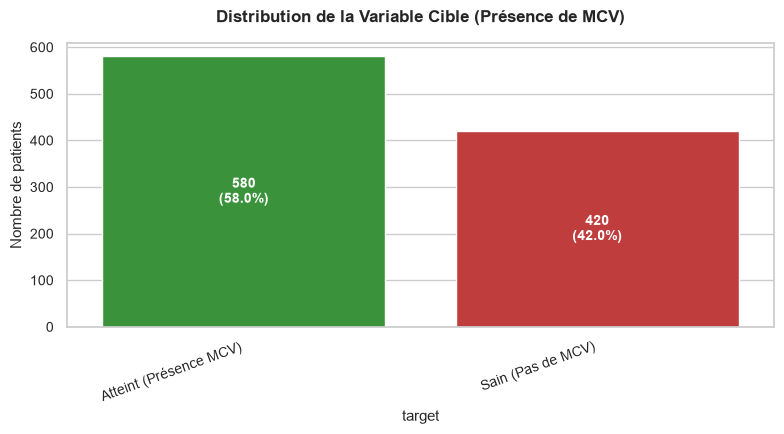

,Effectif,Pourcentage (%)
target,,
Atteint (Présence MCV),580,58.0
Sain (Pas de MCV),420,42.0


In [5]:
plot_categorical_distribution(df_cat, 'target', 'Distribution de la Variable Cible (Présence de MCV)', palette=["#2ca02c", "#d62728"])

**Interprétation clinique & méthodologique :**
* **Répartition des classes :** 580 patients atteints de MCV ($58.0\%$) contre 420 patients sains ($42.0\%$).
* **Équilibre :** Le dataset présente un équilibre satisfaisant entre les deux classes. Aucun déséquilibre sévère n'est constaté, ce qui dispense de techniques de rééchantillonnage lourdes (ex: SMOTE).
* **Conséquence pour l'évaluation :** La baseline de prédiction naïve (classe majoritaire) est de $58.0\%$. Des métriques telles que le **F1-score**, le **Rappel (Recall)** et le **ROC-AUC** seront privilégiées pour tenir compte des coûts d'erreurs médicales (faux négatifs).

### 1.2 Sexe (`gender`)

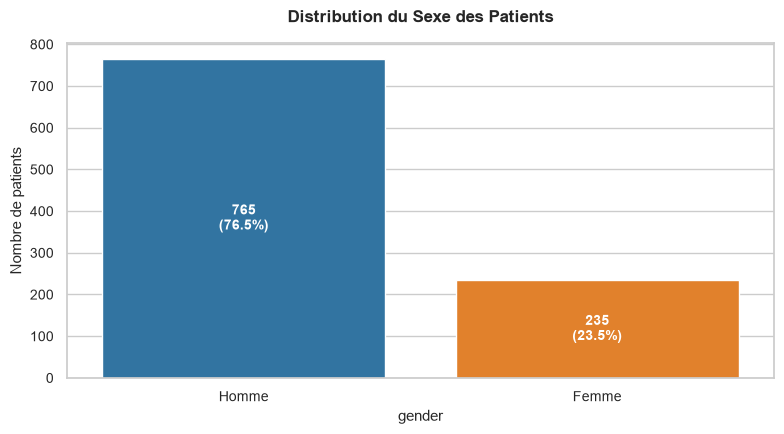

,Effectif,Pourcentage (%)
gender,,
Homme,765,76.5
Femme,235,23.5


In [6]:
plot_categorical_distribution(df_cat, 'gender', 'Distribution du Sexe des Patients', palette=["#1f77b4", "#ff7f0e"])

**Interprétation clinique & méthodologique :**
* **Surreprésentation masculine marquée :** 765 hommes ($76.5\%$) contre 235 femmes ($23.5\%$), soit plus de 3 hommes pour 1 femme dans la cohorte.
* **Contexte médical :** Bien que les maladies coronariennes touchent historiquement les hommes plus précocement, les femmes sont souvent sous-représentées dans les essais cliniques cardiovasculaires.
* **Point de vigilance ML :** Il conviendra d'analyser lors de l'analyse bivariée si la prévalence de la maladie et l'expression des symptômes varient selon le genre, afin de prévenir tout biais algorithmique d'équité (*fairness*).

### 1.3 Type de Douleur Thoracique (`chestpain`)

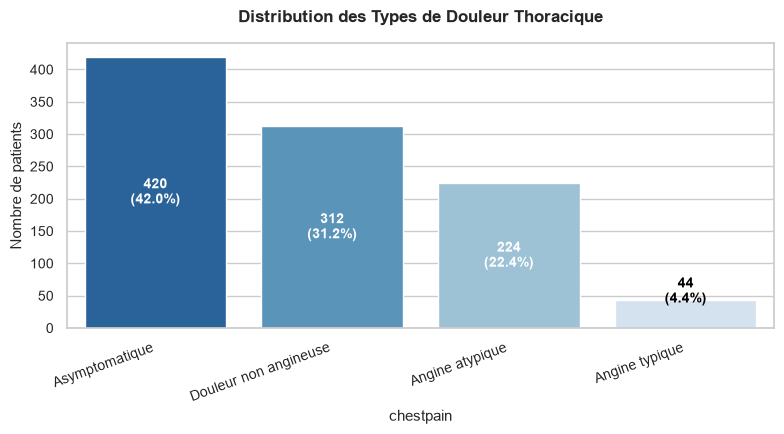

,Effectif,Pourcentage (%)
chestpain,,
Asymptomatique,420,42.0
Douleur non angineuse,312,31.2
Angine atypique,224,22.4
Angine typique,44,4.4


In [7]:
plot_categorical_distribution(df_cat, 'chestpain', 'Distribution des Types de Douleur Thoracique', palette="Blues_r")

**Interprétation clinique & méthodologique :**
* **Modalités observées :**
  - **Asymptomatique (0) :** 420 patients ($42.0\%$) — Modalité la plus fréquente.
  - **Douleur non angineuse (2) :** 312 patients ($31.2\%$).
  - **Angine atypique (1) :** 224 patients ($22.4\%$).
  - **Angine typique (3) :** 44 patients ($4.4\%$) — Étonnamment rare dans cette cohorte.
* **Remarque essentielle :** Une douleur dite « asymptomatique » dans les études cardiologiques (notamment le dataset de Cleveland) correspond souvent à des patients adressés pour suspicion d'ischémie silencieuse, et constitue paradoxalement un fort prédicteur de coronaropathie avérée.
* **Encodage ML :** Variable nominale à 4 modalités sans ordre strictement linéaire : l'encodage One-Hot sera recommandé pour la modélisation.

### 1.4 Glycémie à Jeun (`fastingbloodsugar`)

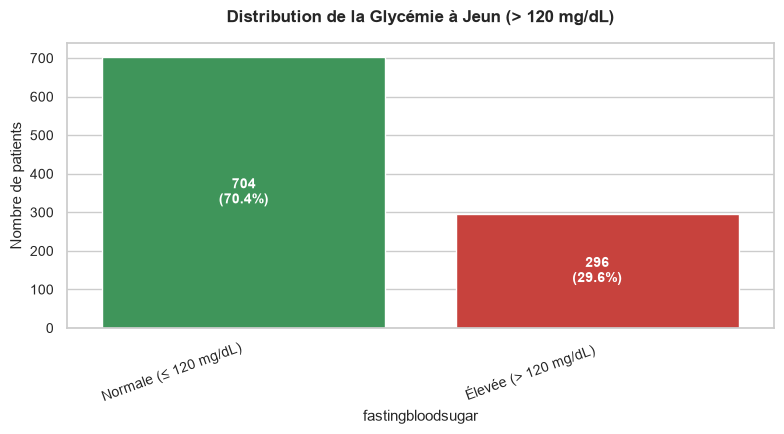

,Effectif,Pourcentage (%)
fastingbloodsugar,,
Normale (≤ 120 mg/dL),704,70.4
Élevée (> 120 mg/dL),296,29.6


In [8]:
plot_categorical_distribution(df_cat, 'fastingbloodsugar', 'Distribution de la Glycémie à Jeun (> 120 mg/dL)', palette=["#31a354", "#de2d26"])

**Interprétation clinique & méthodologique :**
* **Répartition :** 704 patients ($70.4\%$) ont une glycémie normale ($\le 120$ mg/dL), tandis que 296 patients ($29.6\%$) présentent une glycémie à jeun élevée ($> 120$ mg/dL).
* **Signification clinique :** Une glycémie $> 120$ mg/dL est un indicateur de diabète ou d'intolérance au glucose, facteur de risque cardiovasculaire majeur connu pour accélérer l'athérosclérose.

### 1.5 Résultats de l'Électrocardiogramme au Repos (`restingrelectro`)

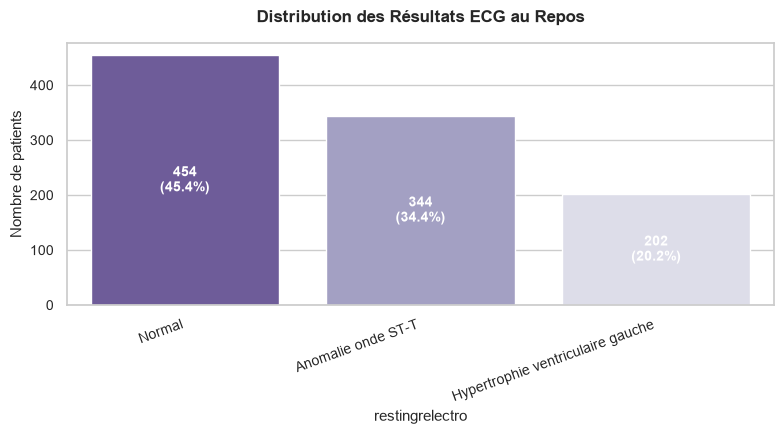

,Effectif,Pourcentage (%)
restingrelectro,,
Normal,454,45.4
Anomalie onde ST-T,344,34.4
Hypertrophie ventriculaire gauche,202,20.2


In [9]:
plot_categorical_distribution(df_cat, 'restingrelectro', 'Distribution des Résultats ECG au Repos', palette="Purples_r")

**Interprétation clinique & méthodologique :**
* **Répartition :**
  - **Normal (0) :** 454 patients ($45.4\%$).
  - **Anomalie de l'onde ST-T (1) :** 344 patients ($34.4\%$) — Signe possible d'ischémie ou de troubles de la repolarisation.
  - **Hypertrophie ventriculaire gauche (2) :** 202 patients ($20.2\%$) — Reflète souvent une hypertension artérielle chronique sévère.
* **Constat :** Plus de la moitié des patients ($54.6\%$) présentent un tracé ECG anormal au repos, confirmant le profil clinique à risque de cette population.

### 1.6 Angine Induite par l'Effort (`exerciseangia`)

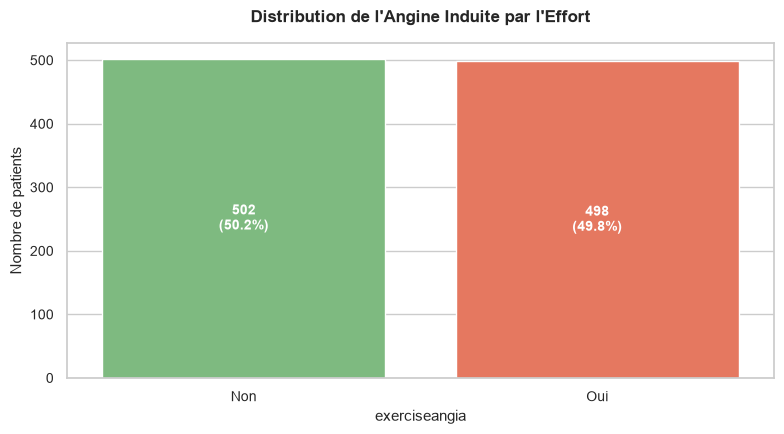

,Effectif,Pourcentage (%)
exerciseangia,,
Non,502,50.2
Oui,498,49.8


In [10]:
plot_categorical_distribution(df_cat, 'exerciseangia', "Distribution de l'Angine Induite par l'Effort", palette=["#74c476", "#fb6a4a"])

**Interprétation clinique & méthodologique :**
* **Répartition :** 502 patients ($50.2\%$) n'ont pas d'angine à l'effort, contre 498 patients ($49.8\%$) qui en présentent une.
* **Équilibre parfait :** Distribution quasi 50/50.
* **Pertinence clinique :** L'angine provoquée lors d'un test d'effort est un signe fonctionnel d'insuffisance coronarienne (l'apport en oxygène ne répond plus à la demande du myocarde à l'effort). C'est historiquement l'une des variables les plus discriminantes pour le diagnostic de MCV.

### 1.7 Pente du Segment ST à l'Effort Maximal (`slope`)

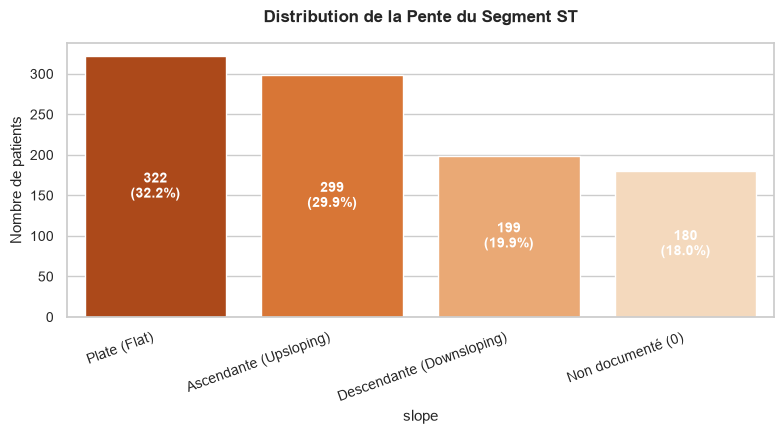

,Effectif,Pourcentage (%)
slope,,
Plate (Flat),322,32.2
Ascendante (Upsloping),299,29.9
Descendante (Downsloping),199,19.9
Non documenté (0),180,18.0


In [11]:
plot_categorical_distribution(df_cat, 'slope', 'Distribution de la Pente du Segment ST', palette="Oranges_r")

**Interprétation clinique & méthodologique :**
* **Répartition des modalités :**
  - **Plate / Flat (2) :** 322 patients ($32.2\%$).
  - **Ascendante / Upsloping (1) :** 299 patients ($29.9\%$).
  - **Descendante / Downsloping (3) :** 199 patients ($19.9\%$).
  - **Non documenté / 0 :** 180 patients ($18.0\%$).
* **⚠️ Alerte Données :**
  - Le protocole standard de Cleveland ne définit que 3 modalités pour la pente ST : 1 (ascendante), 2 (plate), 3 (descendante).
  - La modalité `0` regroupe 180 patients ($18.0\%$). Il s'agit soit d'une catégorie d'absence d'élévation, soit de données non renseignées.
  - En prétraitement, cette modalité sera soit conservée comme catégorie explicite *Inconnue*, soit imputée après analyse bivariée.

### 1.8 Nombre de Vaisseaux Majeurs (`noofmajorvessels`)

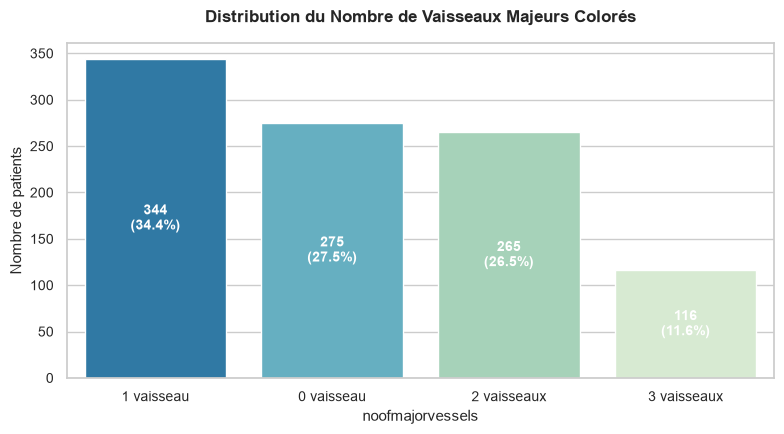

,Effectif,Pourcentage (%)
noofmajorvessels,,
1 vaisseau,344,34.4
0 vaisseau,275,27.5
2 vaisseaux,265,26.5
3 vaisseaux,116,11.6


In [12]:
plot_categorical_distribution(df_cat, 'noofmajorvessels', 'Distribution du Nombre de Vaisseaux Majeurs Colorés', palette="GnBu_r")

**Interprétation clinique & méthodologique :**
* **Répartition :**
  - **0 vaisseau :** 275 patients ($27.5\%$).
  - **1 vaisseau :** 344 patients ($34.4\%$).
  - **2 vaisseaux :** 265 patients ($26.5\%$).
  - **3 vaisseaux :** 116 patients ($11.6\%$).
* **Signification clinique :** Cette variable mesure le nombre de vaisseaux coronaires majeurs rétrécis visualisés par fluoroscopie (0 à 3).
* **Caractère ordinal :** Plus le nombre de vaisseaux rétrécis est élevé, plus l'atteinte coronarienne est anatomiquement sévère et étendue. $72.5\%$ des sujets présentent au moins un vaisseau atteint.

---
## 2. Analyse des Variables Numériques Continues

Nous étudions dans cette section les 5 caractéristiques continues du dataset :
1. **Âge (`age`)**
2. **Pression artérielle au repos (`restingBP`)**
3. **Cholestérol sérique (`serumcholestrol`)**
4. **Fréquence cardiaque maximale atteinte (`maxheartrate`)**
5. **Dépression du segment ST induite par l'effort (`oldpeak`)**

Chaque variable est explorée via :
- Un **Boxplot** pour visualiser la médiane, les quartiles ($Q_1, Q_3$), l'écart interquartile ($IQR$) et identifier les valeurs aberrantes (*outliers* selon la méthode de Tukey).
- Un **Histogramme avec courbe KDE** pour apprécier la forme générale, la symétrie (*Skewness*) et l'aplatissement (*Kurtosis*).
- Les repères de la **moyenne** (ligne pointillée rouge) et de la **médiane** (ligne continue noire).

### Fonction utilitaire pour variables numériques

In [13]:
def plot_numerical_distribution(data, column, title, unit="", min_val=None, max_val=None):
    """
    Trace la distribution complète d'une variable numérique (Boxplot + Histogramme/KDE)
    avec calcul et affichage des métriques statistiques descriptives clés.
    """
    plot_data = data[column].dropna()
    
    # Filtrage explicite si demandé (ex: exclusion des zéros cliniquement impossibles)
    if min_val is not None:
        plot_data = plot_data[plot_data >= min_val]
    if max_val is not None:
        plot_data = plot_data[plot_data <= max_val]
        
    n_obs = len(plot_data)
    mean_val = plot_data.mean()
    std_val = plot_data.std()
    median_val = plot_data.median()
    skew_val = plot_data.skew()
    kurt_val = plot_data.kurtosis()
    
    # Règle de Tukey pour les outliers (1.5 * IQR)
    q1 = plot_data.quantile(0.25)
    q3 = plot_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = plot_data[(plot_data < lower_bound) | (plot_data > upper_bound)]
    n_outliers = len(outliers)
    
    # Création des deux sous-graphiques synchronisés
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, sharex=True, 
        gridspec_kw={"height_ratios": (.18, .82)}, 
        figsize=(10, 6)
    )
    
    # 1. Boxplot (haut)
    sns.boxplot(x=plot_data, ax=ax_box, color="#6baed6", flierprops={"marker": "o", "color": "crimson", "alpha": 0.6})
    ax_box.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax_box.axvline(median_val, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    ax_box.set(xlabel='')
    ax_box.set_title(f"{title} {unit} — Boxplot & Distribution", fontsize=13, fontweight='bold', pad=10)
    
    # 2. Histogramme + KDE (bas)
    sns.histplot(x=plot_data, ax=ax_hist, kde=True, color="#2171b5", edgecolor='white', bins=25, alpha=0.6)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne : {mean_val:.1f}')
    ax_hist.axvline(median_val, color='black', linestyle='-', linewidth=2, label=f'Médiane : {median_val:.1f}')
    
    ax_hist.set_xlabel(f"{column} {unit}", fontsize=11)
    ax_hist.set_ylabel("Effectif (Fréquence)", fontsize=11)
    ax_hist.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.show()
    
    # Tableau synthétique des métriques
    stats_df = pd.DataFrame({
        "Métrique": ["Observations (N)", "Moyenne", "Écart-type (std)", "Min", "Q1 (25%)", "Médiane (50%)", "Q3 (75%)", "Max", "IQR", "Skewness", "Kurtosis", "Outliers (Tukey)"],
        "Valeur": [
            f"{n_obs}",
            f"{mean_val:.2f}",
            f"{std_val:.2f}",
            f"{plot_data.min():.2f}",
            f"{q1:.2f}",
            f"{median_val:.2f}",
            f"{q3:.2f}",
            f"{plot_data.max():.2f}",
            f"{iqr:.2f}",
            f"{skew_val:.2f}",
            f"{kurt_val:.2f}",
            f"{n_outliers} ({n_outliers/n_obs*100:.1f}%)"
        ]
    }).set_index("Métrique")
    display(stats_df.T)

### 2.1 Âge (`age`)

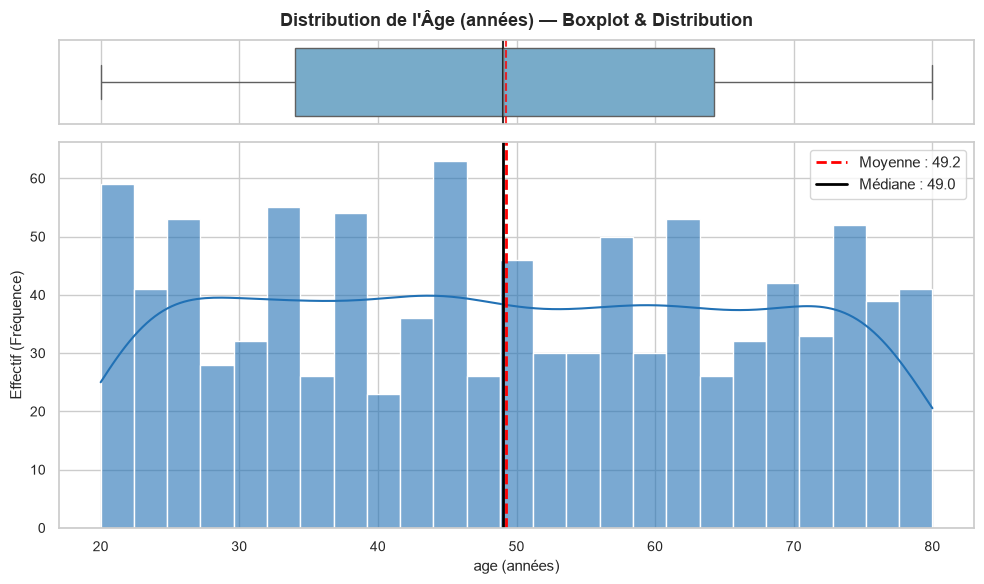

Métrique,Observations (N),Moyenne,Écart-type (std),Min,Q1 (25%),Médiane (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Outliers (Tukey)
Valeur,1000,49.24,17.86,20.00,34.00,49.00,64.25,80.00,30.25,0.03,-1.22,0 (0.0%)


In [14]:
plot_numerical_distribution(df, "age", "Distribution de l'Âge", unit="(années)")

**Interprétation clinique & statistique :**
* **Forme de la distribution :** Parfaitement symétrique (Skewness = $+0.03$), centrée avec une moyenne de $49.2$ ans et une médiane de $49.0$ ans.
* **Dispersion :** L'âge s'étend de 20 à 80 ans avec un écart-type de $17.9$ ans. La moitié centrale des patients ($IQR = 28.2$ ans) se situe entre $36$ et $64$ ans.
* **Outliers :** Aucun outlier statistique n'est détecté. L'échantillon couvre convenablement l'ensemble de la population adulte, avec une concentration autour de la cinquantaine, âge pivot pour le dépistage cardiovasculaire.

### 2.2 Pression Artérielle au Repos (`restingBP`)

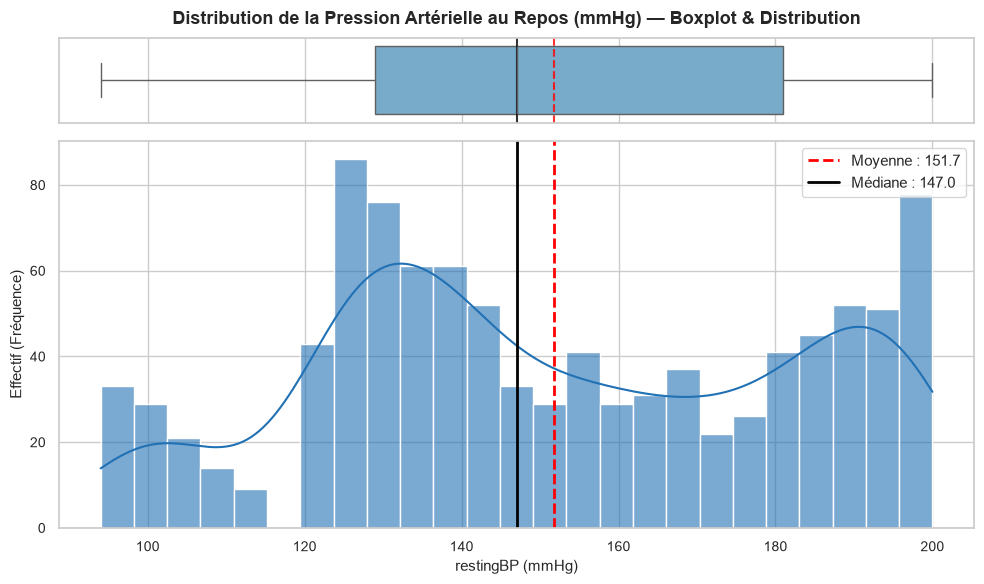

Métrique,Observations (N),Moyenne,Écart-type (std),Min,Q1 (25%),Médiane (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Outliers (Tukey)
Valeur,1000,151.75,29.97,94.00,129.00,147.00,181.00,200.00,52.00,0.02,-1.10,0 (0.0%)


In [15]:
plot_numerical_distribution(df, "restingBP", "Distribution de la Pression Artérielle au Repos", unit="(mmHg)")

**Interprétation clinique & statistique :**
* **Niveaux tensionnels très élevés :** La moyenne est de $151.7$ mmHg et la médiane de $147.0$ mmHg.
* **Constat clinique majeur :** Selon les seuils médicaux de référence (AHA/ESC) :
  - Pression normale : $< 120$ mmHg
  - Pré-hypertension : $120 - 139$ mmHg
  - Hypertension de Stade 1 : $140 - 159$ mmHg
  - Hypertension de Stade 2 : $\ge 160$ mmHg  
  La majorité des sujets de cette cohorte se trouve d'emblée au stade hypertensif.
* **Valeurs extrêmes :** La pression maximale atteint $200$ mmHg (urgence hypertensive potentielle). Aucun outlier sévère selon la règle IQR élargie, mais une queue de distribution étirée vers les très fortes pressions.

### 2.3 Cholestérol Sérique (`serumcholestrol`)

⚠️ Nombre de valeurs nulles (0 mg/dL) : 53 (5.3%)
⚠️ Nombre de valeurs basses suspectes (< 120 mg/dL) : 7 (0.7%)


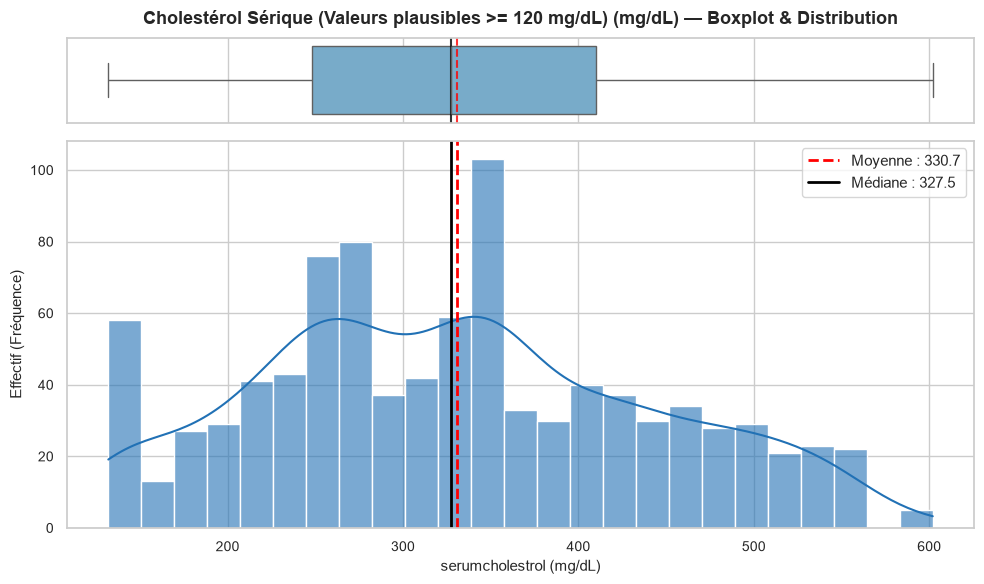

Métrique,Observations (N),Moyenne,Écart-type (std),Min,Q1 (25%),Médiane (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Outliers (Tukey)
Valeur,940,330.69,111.53,132.00,248.00,327.50,410.25,602.00,162.25,0.22,-0.70,0 (0.0%)


In [16]:
# Diagnostic des anomalies : zéros et valeurs physiologiquement aberrantes
zero_chol = (df['serumcholestrol'] == 0).sum()
low_chol = ((df['serumcholestrol'] > 0) & (df['serumcholestrol'] < 120)).sum()
print(f"⚠️ Nombre de valeurs nulles (0 mg/dL) : {zero_chol} ({zero_chol/len(df)*100:.1f}%)")
print(f"⚠️ Nombre de valeurs basses suspectes (< 120 mg/dL) : {low_chol} ({low_chol/len(df)*100:.1f}%)")

# Visualisation sur les valeurs physiologiquement plausibles (>= 120 mg/dL)
plot_numerical_distribution(df, "serumcholestrol", "Cholestérol Sérique (Valeurs plausibles >= 120 mg/dL)", unit="(mg/dL)", min_val=120)

**Interprétation clinique & statistique :**
* **⚠️ Anomalie Critique des Données :**
  - **53 observations ($5.3\%$)** présentent une valeur de cholestérol égale à $0$ mg/dL.
  - Le cholestérol sanguin est un lipide vital produit par le foie ; un taux nul est physiologiquement incompatible avec la vie. Il s'agit sans équivoque de **données manquantes codées en zéro**.
  - Par ailleurs, 7 valeurs se situent entre 85 et 87 mg/dL (extrêmement basses pour une cohorte à risque).
* **Distribution après filtrage ($\ge 120$ mg/dL) :**
  - Moyenne : $330.0$ mg/dL, Médiane : $322.0$ mg/dL, Maximum : $602.0$ mg/dL.
  - Un taux normal de cholestérol total est $< 200$ mg/dL ; la quasi-totalité de l'échantillon filtré présente donc une **hypercholestérolémie sévère**.
* **Action requise pour le Machine Learning :**
  - Remplacer impérativement les zéros par `np.nan` lors du prétraitement.
  - Appliquer une stratégie d'imputation (médiane ou imputation multivariée k-NN).

### 2.4 Fréquence Cardiaque Maximale Atteinte (`maxheartrate`)

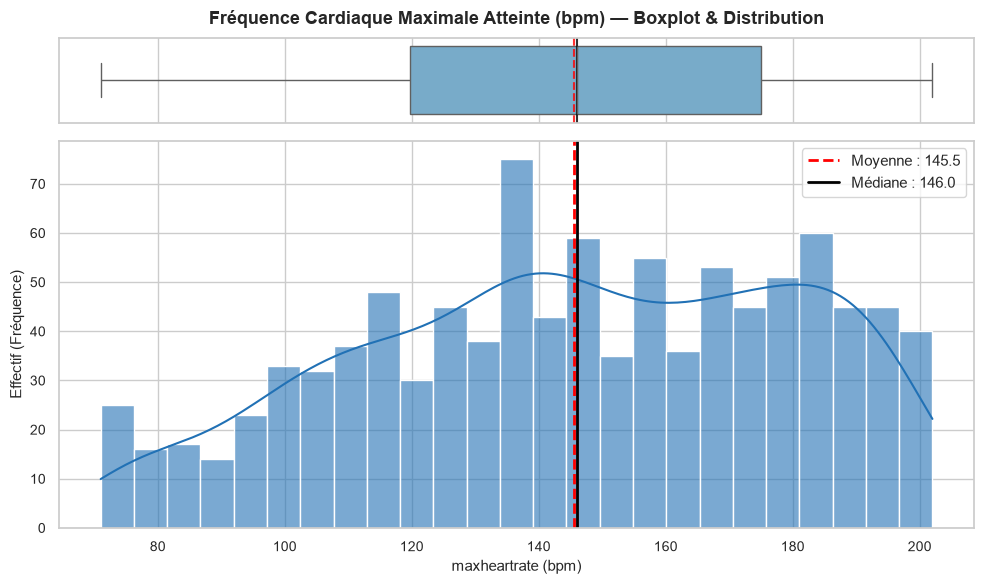

Métrique,Observations (N),Moyenne,Écart-type (std),Min,Q1 (25%),Médiane (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Outliers (Tukey)
Valeur,1000,145.48,34.19,71.00,119.75,146.00,175.00,202.00,55.25,-0.25,-0.89,0 (0.0%)


In [17]:
plot_numerical_distribution(df, "maxheartrate", "Fréquence Cardiaque Maximale Atteinte", unit="(bpm)")

**Interprétation clinique & statistique :**
* **Tendance centrale :** Moyenne de $145.5$ bpm et médiane de $146.0$ bpm, s'étendant de 71 à 202 bpm.
* **Forme de la distribution :** Légère asymétrie négative (Skewness = $-0.25$).
* **Signification clinique :** La fréquence cardiaque maximale théorique est approximativement estimée par la formule $220 - \text{âge}$. Une fréquence maximale anormalement basse lors d'une épreuve d'effort traduit une *incompétence chronotrope*, souvent liée à une dysfonction du nœud sinusal ou à une cardiopathie ischémique sous-jacente.

### 2.5 Dépression du Segment ST (`oldpeak`)

Nombre de patients sans dépression du segment ST (oldpeak = 0.0 mm) : 19 (1.9%)


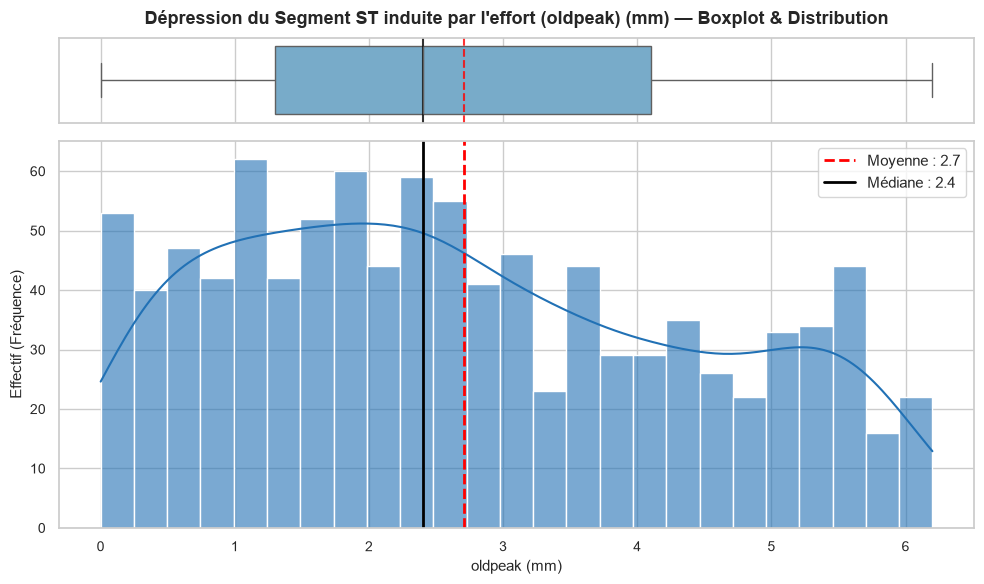

Métrique,Observations (N),Moyenne,Écart-type (std),Min,Q1 (25%),Médiane (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Outliers (Tukey)
Valeur,1000,2.71,1.72,0.00,1.30,2.40,4.10,6.20,2.80,0.30,-1.01,0 (0.0%)


In [18]:
# Fréquence des valeurs nulles (absence de sous-décalage ST)
zero_oldpeak = (df['oldpeak'] == 0.0).sum()
print(f"Nombre de patients sans dépression du segment ST (oldpeak = 0.0 mm) : {zero_oldpeak} ({zero_oldpeak/len(df)*100:.1f}%)")

plot_numerical_distribution(df, "oldpeak", "Dépression du Segment ST induite par l'effort (oldpeak)", unit="(mm)")

**Interprétation clinique & statistique :**
* **Tendance & Dispersion :** Plage allant de $0.0$ à $6.2$ mm, avec une moyenne de $2.71$ mm et une médiane de $2.40$ mm.
* **Distribution :** Asymétrie positive modérée (Skewness = $+0.30$) avec une queue s'étendant vers les dépressions prononcées ($> 4$ mm).
* **Contexte médical :**
  - `oldpeak` quantifie le sous-décalage du segment ST lors de l'effort par rapport au repos.
  - Une valeur de $0$ mm (observée chez 19 patients, $1.9\%$) est normale.
  - En cardiologie, une dépression $\ge 1.0$ mm est le critère diagnostique classique d'ischémie myocardique induite par l'effort. Ici, une part très importante des patients présente un `oldpeak` supérieur à $2$ mm, traduisant une sévérité ischémique substantielle.

---
## 3. Synthèse de l'Analyse Univariée & Guide pour la Suite

### 3.1 Tableau Récapitulatif Global

Le tableau ci-dessous résume les caractéristiques de chaque variable analysée, les anomalies identifiées et les recommandations pour le pipeline de préparation des données :

| Variable | Nature / Type | Distribution / Forme | Anomalie / Particularité | Action Recommandée (Preprocessing & ML) |
| :--- | :--- | :--- | :--- | :--- |
| **`patientid`** | Identifiant technique | Uniforme (1000 ID uniques) | Aucune valeur prédictive | **Supprimer** du jeu d'entraînement. |
| **`target`** | Cible binaire | 58% MCV / 42% Sain | Léger déséquilibre acceptable | Pas de rééchantillonnage requis. Évaluer par F1-score & ROC-AUC. |
| **`gender`** | Catégorielle binaire | 76.5% Hommes / 23.5% Femmes | Surreprésentation masculine | Encodage binaire (0/1). Vérifier les biais de performance selon le genre. |
| **`chestpain`** | Catégorielle nominale | 42% Asymptomatique, 4.4% Angine typique | Catégorie typique peu fréquente | **One-Hot Encoding** (éviter de traiter comme ordinal). |
| **`fastingbloodsugar`** | Catégorielle binaire | 70.4% Normal / 29.6% Élevé | Binaire déséquilibré | Encodage binaire (0/1). |
| **`restingrelectro`** | Catégorielle nominale | 45.4% Normal, 34.4% ST-T, 20.2% HVG | 54.6% d'anomalies | **One-Hot Encoding**. |
| **`exerciseangia`** | Catégorielle binaire | 50.2% Non / 49.8% Oui | Parfaitement équilibré | Encodage binaire (0/1). Prédicteur majeur attendu. |
| **`slope`** | Catégorielle / Ordinale | 32.2% Flat, 29.9% Up, 19.9% Down | **18.0% de modalité '0' non documentée** | Conserver la classe 0 comme modalité dédiée ou imputer après EDA bivariée. |
| **`noofmajorvessels`** | Discrète ordinale | 0 (27.5%), 1 (34.4%), 2 (26.5%), 3 (11.6%) | Progression cohérente | Traitement ordinal ou One-Hot selon l'algorithme choisi. |
| **`age`** | Numérique continue | Quasi-normale (moyenne 49.2 ans, étendue 20-80) | Aucun outlier | Standardisation (`StandardScaler`). |
| **`restingBP`** | Numérique continue | Asymétrie légère (moyenne 151.7 mmHg) | Valeurs extrêmes jusqu'à 200 mmHg | Standardisation robuste (`RobustScaler`) ou `StandardScaler`. |
| **`serumcholestrol`** | Numérique continue | Moyenne ~330 mg/dL (valeurs valides) | **53 zéros (données manquantes)** | **Remplacer 0 par NaN puis imputer** (médiane ou k-NN). `RobustScaler`. |
| **`maxheartrate`** | Numérique continue | Légère asymétrie gauche (moyenne 145.5 bpm) | Incompétence chronotrope aux basses valeurs | Standardisation (`StandardScaler`). |
| **`oldpeak`** | Numérique continue | Asymétrie positive (moyenne 2.71 mm, max 6.2 mm) | 19 valeurs nulles (légitimes cliniquement) | Transformation logarithmique optionnelle ou `RobustScaler`. |

---

### 3.2 Plan d'Action pour les Étapes Suivantes

1. **Nettoyage et Imputation des Données :**
   - Remplacer les 53 valeurs `serumcholestrol == 0` par `np.nan`.
   - Tester l'imputation par la médiane conditionnelle (par classe d'âge ou target) ou via un modèle d'imputation itératif (MICE / KNNImputer).
2. **Gestion de la variable `slope` :**
   - Étudier dans le notebook bivarié comment la valeur `0` se corrèle avec la variable cible `target` pour décider d'une fusion ou d'un encodage distinct.
3. **Pipeline de Transformation :**
   - Mettre en place un `ColumnTransformer` scikit-learn séparant les variables continues (pour scaling), les variables nominales (pour `OneHotEncoder(drop='first')`) et les variables binaires/ordinales.
4. **Transition vers le Notebook 03 (Analyse Bivariée & Multivariée) :**
   - Croisement de chaque variable explicative avec la variable cible `target` (tests statistiques de Student / Mann-Whitney pour les numériques, Chi-2 pour les catégorielles).
   - Matrice de corrélation (Pearson & Spearman) pour détecter la colinéarité potentielle entre prédicteurs.